# Adaptive Java ITS: Training, Evaluation, and Explainability

This notebook trains and evaluates the machine-learning component of the Java Intelligent Tutoring System using the attached CSEDM2021-style dataset.

The deployed app treats every launch as a new student session. The historical dataset is used to learn general patterns of student success/struggle, while generated Java questions, misconception maps, and pedagogical rules drive the interactive tutoring experience.


## 1. Setup

The notebook uses relative paths so it can be run from the project root or from the `notebooks/` folder. It saves models, metrics, and figures to the project directories.


In [1]:
from pathlib import Path
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.content_generation import generate_all_content
from src.data_processing import inspect_raw_files, load_label_frames, load_subjects, build_event_aggregates, summarize_labels, code_state_sample
from src.feature_engineering import make_feature_bundle, split_xy
from src.model_training import subject_wise_split, train_models, save_model_package
from src.evaluation import compute_metrics, save_all_figures, leakage_diagnostic_text
from src.utils import ensure_dir, write_json

pd.set_option('display.max_columns', 80)
ensure_dir(ROOT / 'reports' / 'figures')
ensure_dir(ROOT / 'models')
ensure_dir(ROOT / 'data' / 'generated')
print('Project root:', ROOT)


Project root: C:\Users\Louis\java_its_project_complete\java_its_project


## 2. Generate tutoring content

The Java question bank, misconception map, and pedagogical policy are generated educational content. They are not treated as historical CSEDM data.


In [2]:
content_paths = generate_all_content(ROOT / 'data' / 'generated', min_questions=240)
content_paths


{'question_bank': WindowsPath('C:/Users/Louis/java_its_project_complete/java_its_project/data/generated/question_bank.json'),
 'misconception_hint_map': WindowsPath('C:/Users/Louis/java_its_project_complete/java_its_project/data/generated/misconception_hint_map.json'),
 'pedagogical_policy': WindowsPath('C:/Users/Louis/java_its_project_complete/java_its_project/data/generated/pedagogical_policy.json')}

## 3. Raw dataset inspection

This section verifies the attached files, schemas, estimated row counts, and basic structure before modeling.


In [3]:
raw_summary = inspect_raw_files(ROOT)
write_json(raw_summary, ROOT / 'reports' / 'raw_file_summary.json')
pd.DataFrame(raw_summary).T


,exists,size_mb,rows_estimate,columns,dtypes
DatasetMetadata.csv,True,0.0,5,"[Property, Value]","{'Property': 'object', 'Value': 'object'}"
MainTable.csv,True,84.3,361323,"[SubjectID, ToolInstances, ServerTimestamp, Se...","{'SubjectID': 'object', 'ToolInstances': 'obje..."
early.csv,True,1.17,14317,"[SubjectID, AssignmentID, ProblemID, Attempts,...","{'SubjectID': 'object', 'AssignmentID': 'int64..."
late.csv,True,0.77,9386,"[SubjectID, AssignmentID, ProblemID, Attempts,...","{'SubjectID': 'object', 'AssignmentID': 'int64..."
Subject.csv,True,0.03,506,"[SubjectID, X-Grade]","{'SubjectID': 'object', 'X-Grade': 'float64'}"
CodeStates.csv,True,49.38,2322925,"[CodeStateID, Code]","{'CodeStateID': 'object', 'Code': 'object'}"


In [4]:
labels = load_label_frames(ROOT)
subjects = load_subjects(ROOT)
print(labels.shape)
display(labels.head())
display(pd.DataFrame([summarize_labels(labels)]).T)


(23703, 7)


,SubjectID,AssignmentID,ProblemID,Attempts,CorrectEventually,Label,Phase
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,1,1,1,early
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,3,4,1,1,early
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,5,3,1,1,early
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,12,1,1,1,early
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,13,6,1,1,early


,0
rows,23703
students,494
assignments,5
problems,50
label_distribution,"{1: 17575, 0: 6128}"
phase_distribution,"{'early': 14317, 'late': 9386}"
attempts_summary,"{'count': 23703.0, 'mean': 5.102645234780407, ..."


In [5]:
print('Label distribution:')
display(labels['Label'].value_counts(normalize=True).rename('proportion'))
print('Phase distribution:')
display(labels['Phase'].value_counts())
print('Attempts summary by phase:')
display(labels.groupby('Phase')['Attempts'].describe())


Label distribution:


Label
1    0.741467
0    0.258533
Name: proportion, dtype: float64

Phase distribution:


Phase
early    14317
late      9386
Name: count, dtype: int64

Attempts summary by phase:


,count,mean,std,min,25%,50%,75%,max
Phase,,,,,,,,
early,14317.0,5.714186,8.170826,1.0,1.0,3.0,7.0,177.0
late,9386.0,4.169827,5.419133,1.0,1.0,2.0,5.0,102.0


## 4. Event-log aggregation from `MainTable.csv`

`MainTable.csv` contains event-level logs such as compile, run, score, and compiler error events. The current-problem aggregates are useful for exploratory analysis and leakage audits. They are **not** used as deployed model features because they summarize behavior that happens during the current problem.


In [6]:
event_agg = build_event_aggregates(ROOT, cache=True)
print(event_agg.shape)
display(event_agg.head())
write_json({
    'rows': int(len(event_agg)),
    'students': int(event_agg['SubjectID'].nunique()),
    'assignments': int(event_agg['AssignmentID'].nunique()),
    'problems': int(event_agg['ProblemID'].nunique()),
    'note': 'Current-problem event aggregates are used for EDA/leakage documentation, not safe deployed prediction.'
}, ROOT / 'reports' / 'event_aggregate_summary.json')


(24032, 15)


,SubjectID,AssignmentID,ProblemID,event_count,run_count,compile_count,compile_error_event_count,compile_error_result_count,compile_success_count,score_event_count,max_score,mean_score,first_order,last_order,compile_error_count
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,1,2,1,1,0,0,1,1,1.0,1.000000,11161,11162,0
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,3,9,4,4,1,1,3,4,1.0,0.593750,11163,11171,2
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,5,8,3,3,2,2,1,3,1.0,0.333333,11133,11140,4
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,12,2,1,1,0,0,1,1,1.0,1.000000,11172,11173,0
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,439,13,49,6,6,37,5,1,6,1.0,0.166667,11000,11048,42


WindowsPath('C:/Users/Louis/java_its_project_complete/java_its_project/reports/event_aggregate_summary.json')

In [7]:
event_summary = event_agg[['event_count','run_count','compile_count','compile_error_count','compile_success_count','max_score']].describe()
display(event_summary)


,event_count,run_count,compile_count,compile_error_count,compile_success_count,max_score
count,24032.00000,24032.000000,24032.000000,24032.000000,24032.000000,24032.000000
mean,14.98735,5.225449,5.225449,6.625499,3.136401,0.978874
std,24.46127,7.370472,7.370472,16.120476,4.674663,0.109346
min,2.00000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2.00000,1.000000,1.000000,0.000000,1.000000,1.000000
50%,6.00000,3.000000,3.000000,2.000000,1.000000,1.000000
75%,17.00000,6.000000,6.000000,6.000000,3.000000,1.000000
max,641.00000,177.000000,177.000000,582.000000,132.000000,1.000000


## 5. CodeStates sample

`CodeStates.csv` can be large. The notebook samples it for qualitative inspection rather than loading every code state into the predictive model.


In [8]:
sample_code = code_state_sample(ROOT, nrows=5)
display(sample_code)


,CodeStateID,Code
0,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,"public int caughtSpeeding(int speed, boolean i..."
1,cdfe99579672f04db808aa7343826bf3c71751dfba129d...,"public int caughtSpeeding(int speed, boolean i..."
2,511eeec6958a4d834c7419dc55b4831655b13aa6d343ac...,"public int caughtSpeeding(int speed, boolean i..."
3,4c09d5ddc005e6104a8f58f76ee1020eb0adc109b13cb0...,"public int caughtSpeeding(int speed, boolean i..."
4,71514451fe4c010093a06f9f58eced6ae9de98a13edae7...,"public int caughtSpeeding(int speed, boolean i..."


## 6. Thesis-safe feature engineering

The model uses chronological features that are available before each labeled row:

- prior number of items attempted by the same student
- prior success rate
- prior mean attempts
- recent success rate
- current streak before the item
- curricular order and estimated difficulty proxy

The deployed feature set deliberately excludes the row's own `Attempts` and `CorrectEventually`, because those are outcome-proximal and can cause leakage.


In [9]:
bundle = make_feature_bundle(labels, leakage_audit=False)
features_df = bundle.frame
X, y, groups = split_xy(bundle)
print('Feature matrix:', X.shape)
print('Target mean:', y.mean())
display(features_df[['SubjectID','Phase','AssignmentID','ProblemID','Label'] + bundle.features].head(10))


Feature matrix: (23703, 12)
Target mean: 0.7414673248112054


,SubjectID,Phase,AssignmentID,ProblemID,Label,phase_code,assignment_order_norm,problem_order_norm,estimated_difficulty,student_prior_items,student_prior_success_rate,student_prior_mean_attempts,student_prior_incorrect_rate,student_recent_success_rate,student_recent_mean_attempts,student_current_streak,student_prior_compile_success_rate
0,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,early,439,1,1,0,0.0,0.000000,1,0,0.500000,2.000000,0.500000,0.5,2.000000,0,0.5
1,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,early,439,3,1,0,0.0,0.020408,2,1,1.000000,1.000000,0.000000,1.0,1.000000,1,0.5
2,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,early,439,5,1,0,0.0,0.040816,2,2,1.000000,2.500000,0.000000,1.0,2.500000,2,0.5
3,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,early,439,12,1,0,0.0,0.061224,2,3,1.000000,2.666667,0.000000,1.0,2.666667,3,0.5
4,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,early,439,13,1,0,0.0,0.081633,2,4,1.000000,2.250000,0.000000,1.0,2.250000,4,0.5
5,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,early,439,232,1,0,0.0,0.918367,3,5,1.000000,3.000000,0.000000,1.0,3.000000,5,0.5
6,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,early,439,233,0,0,0.0,0.938776,3,6,1.000000,3.000000,0.000000,1.0,3.400000,6,0.5
7,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,early,439,234,1,0,0.0,0.959184,3,7,0.857143,3.571429,0.142857,0.8,4.000000,-1,0.5
8,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,early,439,235,1,0,0.0,0.979592,3,8,0.875000,3.250000,0.125000,0.8,3.600000,1,0.5
9,00358c94503a8d9e6869efc6e5cdb0e1c8e9eb39b1fd46...,early,439,236,0,0,0.0,1.000000,3,9,0.888889,3.000000,0.111111,0.8,3.600000,2,0.5


## 7. Subject-wise split

A subject-wise split is used so the same student does not appear in both training and validation sets. This better simulates predicting for unseen students.


In [10]:
X_train, X_val, y_train, y_val, g_train, g_val = subject_wise_split(X, y, groups, test_size=0.2, random_state=42)
print('Train rows:', len(X_train), 'Validation rows:', len(X_val))
print('Train students:', g_train.nunique(), 'Validation students:', g_val.nunique())
print('Student overlap:', len(set(g_train).intersection(set(g_val))))


Train rows: 19018 Validation rows: 4685
Train students: 395 Validation students: 99
Student overlap: 0


## 8. Model training

The notebook trains:

1. a baseline logistic regression model,
2. a stronger random forest model used by the app,
3. an incremental SGD logistic model used to produce train/validation loss curves.


In [11]:
trained = train_models(X_train, y_train, X_val, y_val, random_state=42)
baseline_model = trained['baseline_model']
final_model = trained['final_model']
loss_model = trained['loss_model']
loss_history = trained['loss_history']
display(loss_history.head())
display(loss_history.tail())
loss_history.to_csv(ROOT / 'reports' / 'loss_history.csv', index=False)


,epoch,train_loss,val_loss,train_auc,val_auc
0,1,0.665824,0.639627,0.640215,0.640060
1,2,0.596981,0.572735,0.751457,0.760329
2,3,0.572424,0.549302,0.753003,0.761567
3,4,0.661834,0.639241,0.753839,0.759674
4,5,0.628915,0.605384,0.739825,0.750634


,epoch,train_loss,val_loss,train_auc,val_auc
30,31,0.587524,0.566964,0.753807,0.760743
31,32,0.598775,0.578980,0.754309,0.761488
32,33,0.595505,0.574851,0.751155,0.756846
33,34,0.586050,0.565445,0.754234,0.760338
34,35,0.592834,0.573584,0.754112,0.760969


## 9. Evaluation metrics

The evaluation includes accuracy, AUC, F1, precision, recall, Brier score, confusion matrix, and classification report.


In [12]:
metrics = {
    'baseline_model': {
        'train': compute_metrics(baseline_model, X_train, y_train),
        'validation': compute_metrics(baseline_model, X_val, y_val),
    },
    'final_model': {
        'train': compute_metrics(final_model, X_train, y_train),
        'validation': compute_metrics(final_model, X_val, y_val),
    },
}
summary_rows = []
for model_name, split_data in metrics.items():
    for split, vals in split_data.items():
        summary_rows.append({
            'model': model_name,
            'split': split,
            'accuracy': vals['accuracy'],
            'auc': vals['auc'],
            'f1': vals['f1'],
            'precision': vals['precision'],
            'recall': vals['recall'],
            'brier_score': vals['brier_score'],
        })
display(pd.DataFrame(summary_rows))


,model,split,accuracy,auc,f1,precision,recall,brier_score
0,baseline_model,train,0.687191,0.755452,0.762771,0.864660,0.682363,0.202676
1,baseline_model,validation,0.705016,0.761743,0.784936,0.879665,0.708626,0.193546
2,final_model,train,0.787202,0.878956,0.844484,0.915133,0.783961,0.147811
3,final_model,validation,0.726574,0.765833,0.807513,0.867894,0.754987,0.178747


## 10. Curves, confusion matrix, calibration, and XAI

The following cell saves all thesis figures into `reports/figures/`.


In [13]:
fig_paths = save_all_figures(
    final_model, X_val, y_val, loss_history, bundle.features, ROOT / 'reports' / 'figures'
)
fig_paths


{'loss_curve': 'C:\\Users\\Louis\\java_its_project_complete\\java_its_project\\reports\\figures\\loss_curve.png',
 'auc_curve': 'C:\\Users\\Louis\\java_its_project_complete\\java_its_project\\reports\\figures\\auc_curve.png',
 'confusion_matrix': 'C:\\Users\\Louis\\java_its_project_complete\\java_its_project\\reports\\figures\\confusion_matrix.png',
 'precision_recall_curve': 'C:\\Users\\Louis\\java_its_project_complete\\java_its_project\\reports\\figures\\precision_recall_curve.png',
 'calibration_curve': 'C:\\Users\\Louis\\java_its_project_complete\\java_its_project\\reports\\figures\\calibration_curve.png',
 'feature_importance': 'C:\\Users\\Louis\\java_its_project_complete\\java_its_project\\reports\\figures\\feature_importance.png',
 'predicted_probability_histogram': 'C:\\Users\\Louis\\java_its_project_complete\\java_its_project\\reports\\figures\\predicted_probability_histogram.png'}

<Figure size 700x600 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 700x600 with 0 Axes>

loss_curve C:\Users\Louis\java_its_project_complete\java_its_project\reports\figures\loss_curve.png


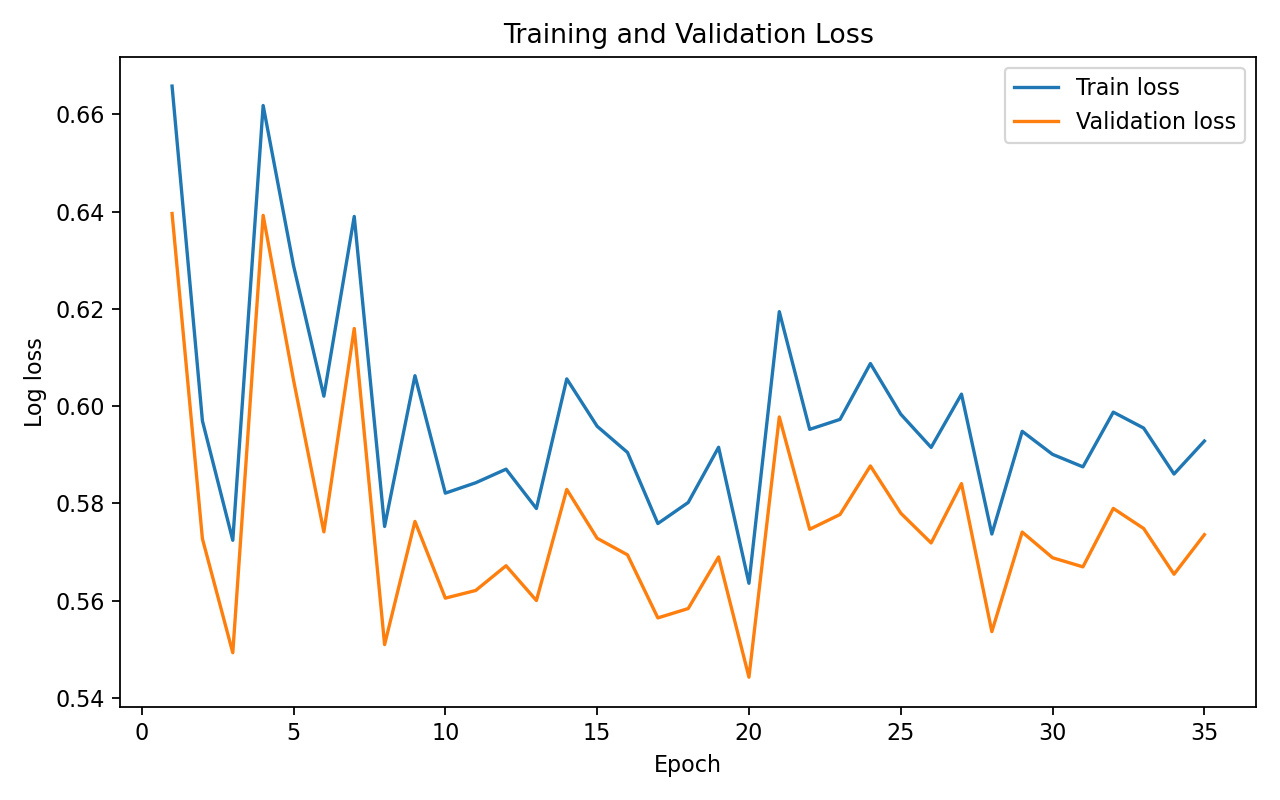

auc_curve C:\Users\Louis\java_its_project_complete\java_its_project\reports\figures\auc_curve.png


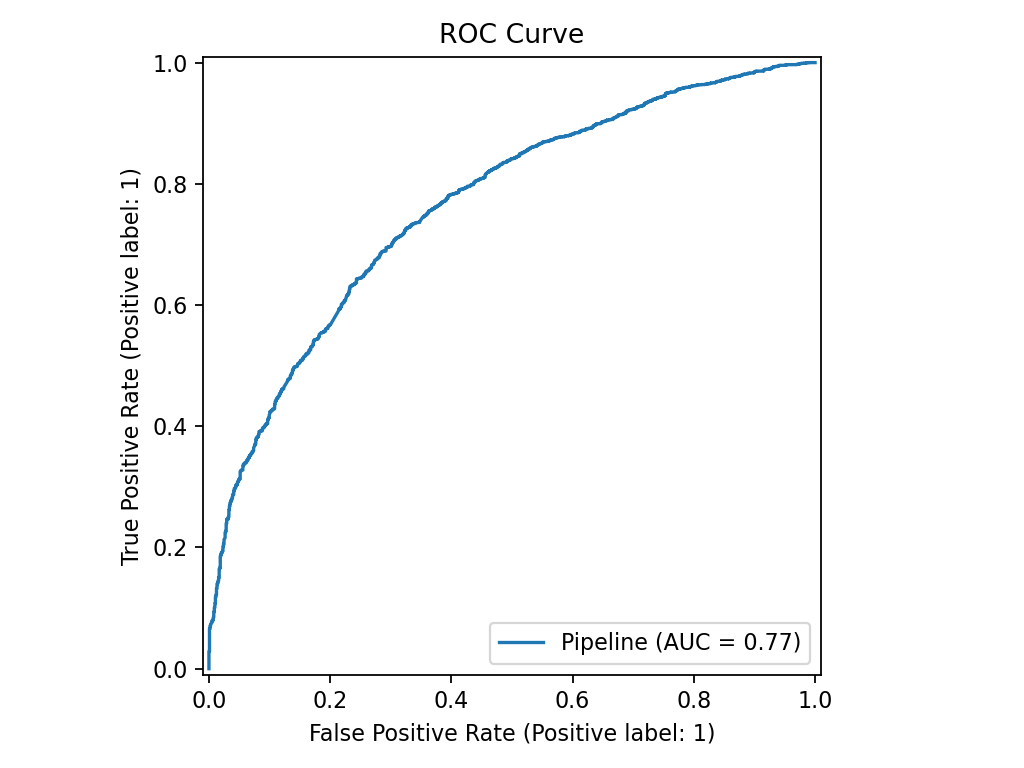

confusion_matrix C:\Users\Louis\java_its_project_complete\java_its_project\reports\figures\confusion_matrix.png


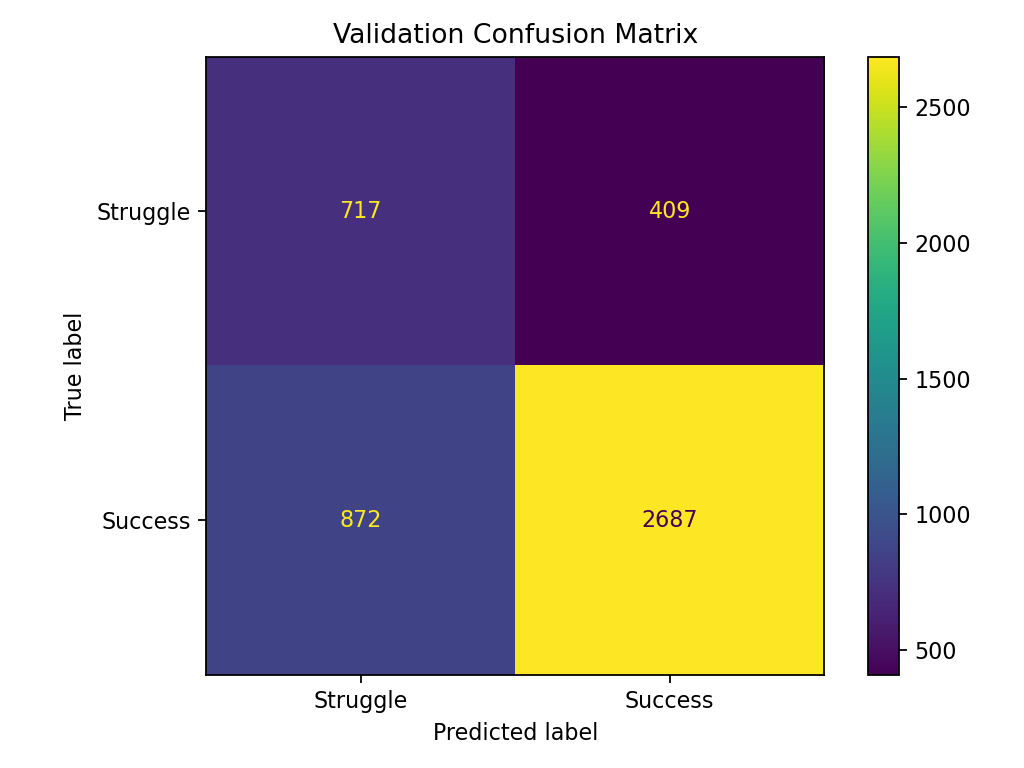

precision_recall_curve C:\Users\Louis\java_its_project_complete\java_its_project\reports\figures\precision_recall_curve.png


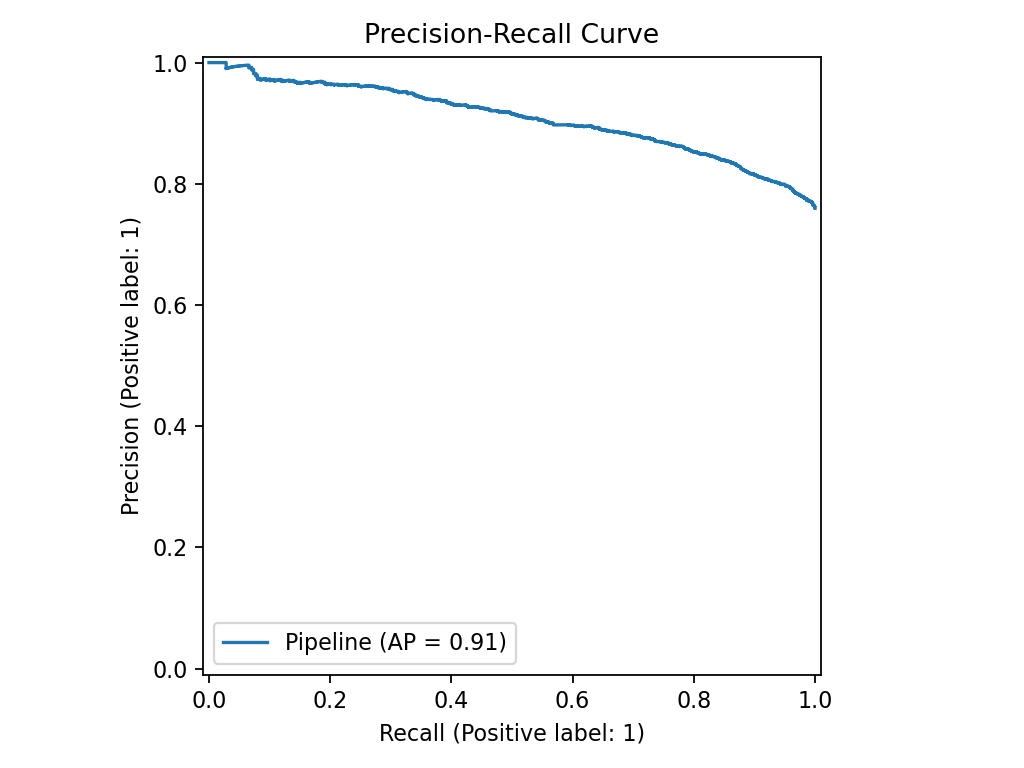

calibration_curve C:\Users\Louis\java_its_project_complete\java_its_project\reports\figures\calibration_curve.png


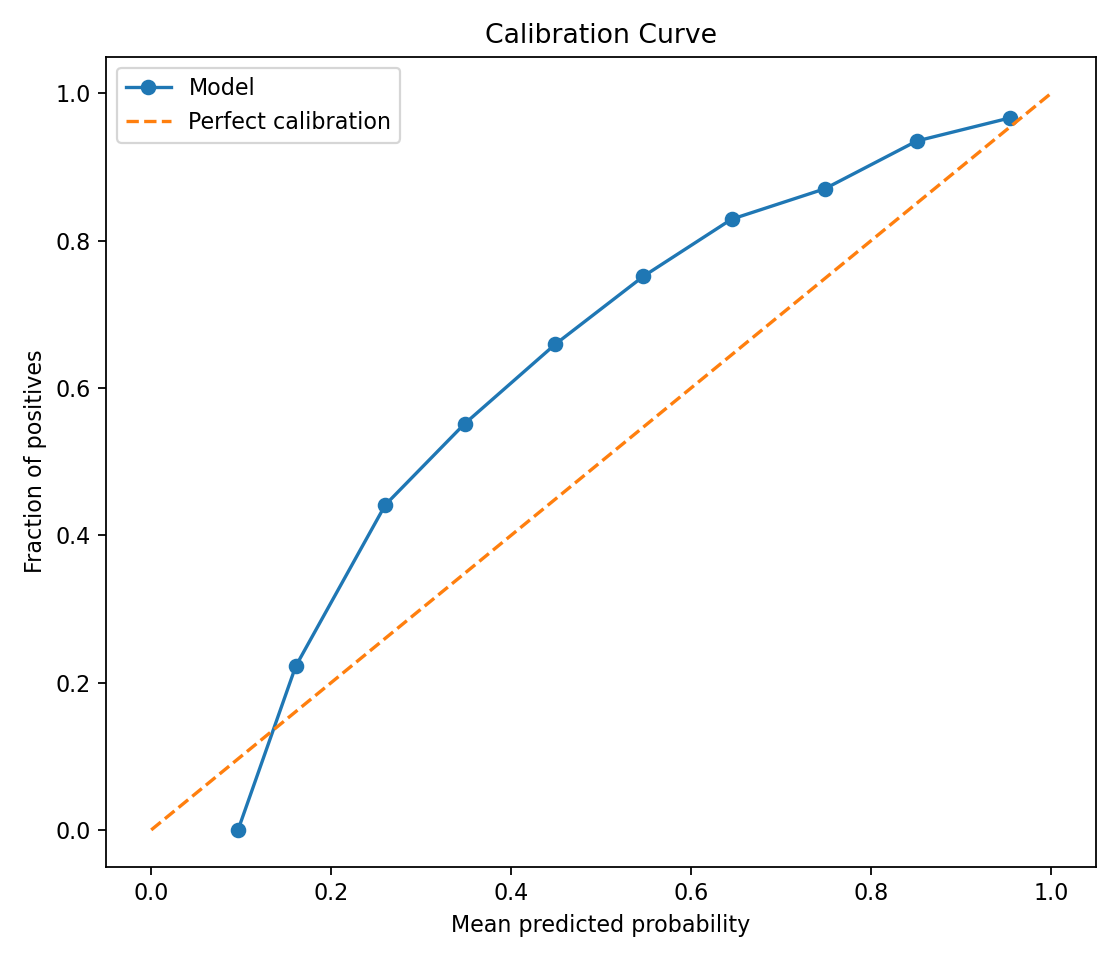

feature_importance C:\Users\Louis\java_its_project_complete\java_its_project\reports\figures\feature_importance.png


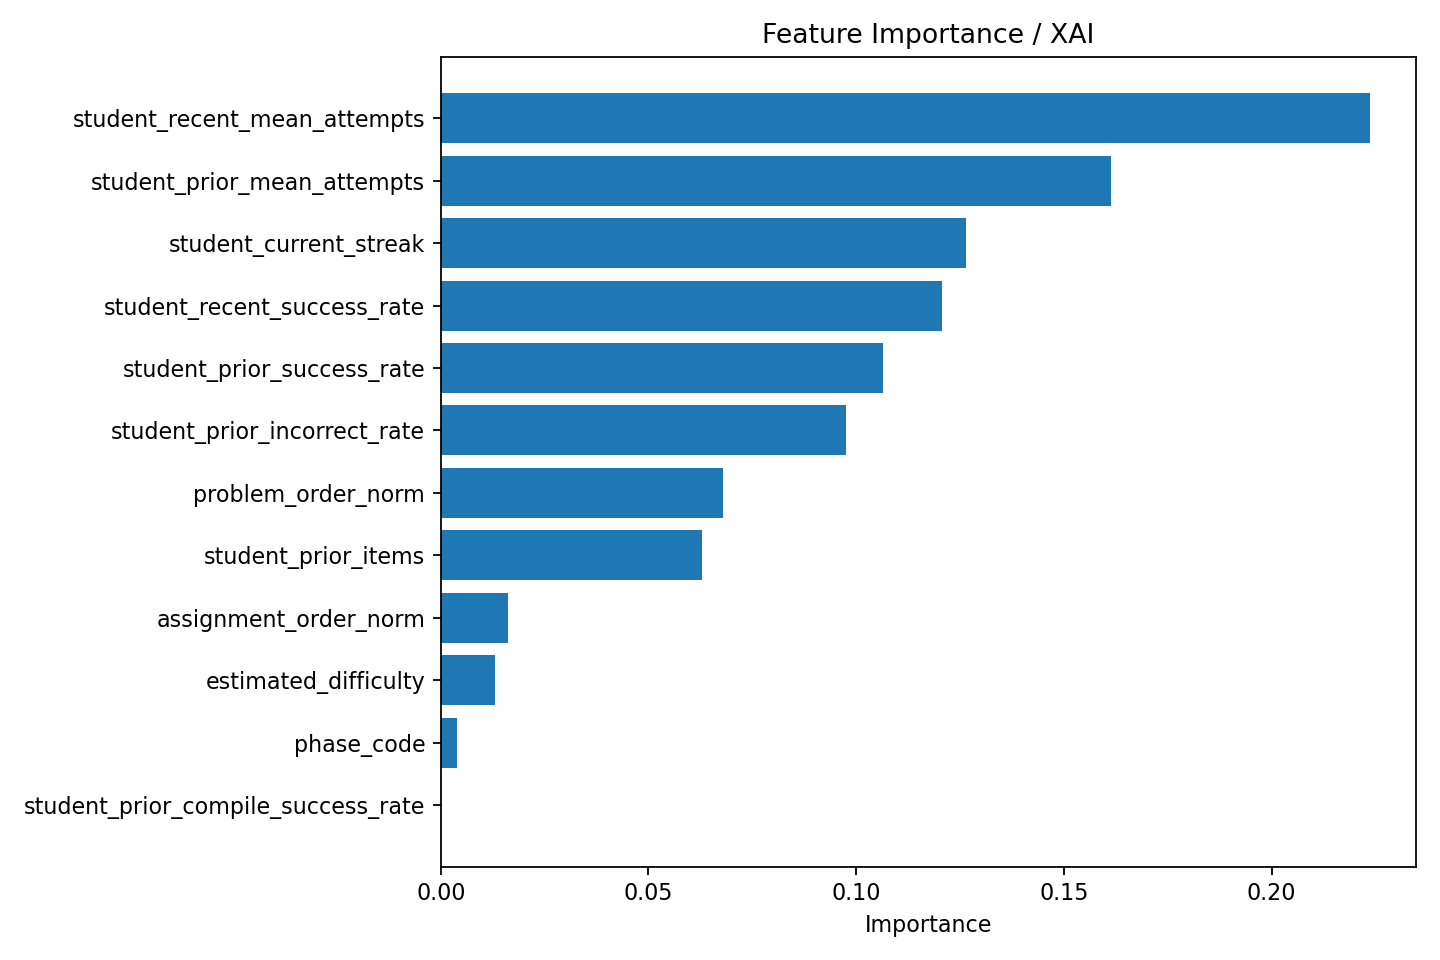

predicted_probability_histogram C:\Users\Louis\java_its_project_complete\java_its_project\reports\figures\predicted_probability_histogram.png


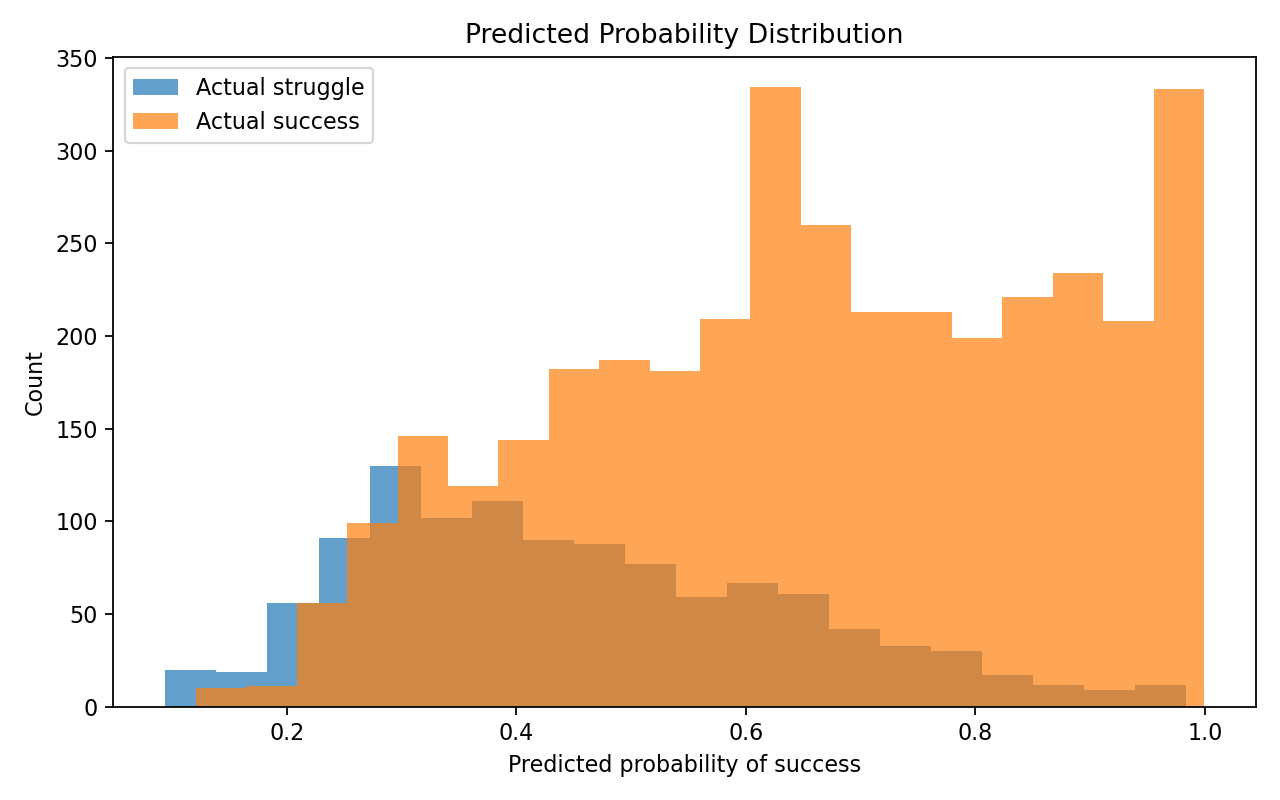

In [14]:
from IPython.display import Image, display
for name, path in fig_paths.items():
    print(name, path)
    display(Image(filename=path))


## 11. Leakage audit

This audit trains a comparison model with current-row `Attempts` and `CorrectEventually`. If the AUC jumps substantially, that is evidence that these fields leak the target and should not be used by the deployed tutor.


In [15]:
leakage_bundle = make_feature_bundle(labels, leakage_audit=True)
X_leak, y_leak, groups_leak = split_xy(leakage_bundle)
Xl_train, Xl_val, yl_train, yl_val, _, _ = subject_wise_split(X_leak, y_leak, groups_leak, test_size=0.2, random_state=42)
leakage_trained = train_models(Xl_train, yl_train, Xl_val, yl_val, random_state=42)
leak_model = leakage_trained['baseline_model']
leakage_metrics = compute_metrics(leak_model, Xl_val, yl_val)
print('Safe final validation AUC:', metrics['final_model']['validation']['auc'])
print('Leakage audit validation AUC:', leakage_metrics['auc'])
print(leakage_diagnostic_text(metrics['final_model']['validation']['auc'], leakage_metrics['auc']))


Safe final validation AUC: 0.7658325751590669
Leakage audit validation AUC: 0.9759242447910559
Leakage audit warning: adding current-row Attempts/CorrectEventually increases AUC substantially. Those fields should not be used in the deployed predictive tutor because they summarize the current outcome.


## 12. Save final artifacts

The app loads `models/its_model.pkl`. The package contains the trained model, feature columns, validation metrics, and a note about the subject-wise split.


In [16]:
all_metrics = {
    'safe_modeling_note': 'Final deployed model excludes current-row Attempts and CorrectEventually to reduce target leakage.',
    'split_strategy': 'GroupShuffleSplit by SubjectID; no student appears in both train and validation sets.',
    'feature_columns': bundle.features,
    'train_rows': int(len(X_train)),
    'validation_rows': int(len(X_val)),
    'train_subjects': int(g_train.nunique()),
    'validation_subjects': int(g_val.nunique()),
    'models': metrics,
    'leakage_audit_model_validation': leakage_metrics,
    'leakage_diagnostic': leakage_diagnostic_text(metrics['final_model']['validation']['auc'], leakage_metrics['auc']),
}
write_json(all_metrics, ROOT / 'reports' / 'metrics.json')
save_model_package(final_model, bundle.features, metrics['final_model']['validation'], ROOT / 'models' / 'its_model.pkl')
import joblib
joblib.dump({'feature_columns': bundle.features, 'preprocessing': 'Median imputation inside models/its_model.pkl Pipeline.'}, ROOT / 'models' / 'preprocessor.pkl')
print('Saved model and metrics.')


Saved model and metrics.


## 13. Thesis discussion notes

- The subject-wise split is more realistic than a random row split because it evaluates generalization to unseen students.
- The deployed model intentionally excludes current-row attempts and final correctness fields to reduce leakage.
- The Streamlit app combines historical ML prediction with an online student model because generated Java tutoring questions are not identical to the original CSEDM problem IDs.
- The tutor uses cold-start diagnostic questions, progressive hints, mastery updates, misconception tracking, and adaptive item selection.
